<a href="https://colab.research.google.com/github/mickael044/CodeAlpha_SpeechEmotion/blob/main/CodeAlpha_SpeechEmotion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mikayilhasanov","key":"dfbf5cbc8174702a9a8d46badcd849be"}'}

In [17]:
# Set up Kaggle API credentials
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API is ready")

Kaggle API is ready


In [18]:
# Download the RAVDESS Emotional Speech Audio dataset from Kaggle
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

# Unzip it
import zipfile
with zipfile.ZipFile("ravdess-emotional-speech-audio.zip", "r") as zip_ref:
    zip_ref.extractall("ravdess_data")

print("Done! Dataset extracted.")

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
ravdess-emotional-speech-audio.zip: Skipping, found more recently modified local copy (use --force to force download)
Done! Dataset extracted.


In [19]:
import os

# Explore the folder structure
for root, dirs, filenames in os.walk("ravdess_data"):
    print(root, "->", len(filenames), "files")
    if filenames:
        print("  Example file:", filenames[0])
    if root.count(os.sep) > 2:  # don't go too deep in the printout
        break

ravdess_data -> 0 files
ravdess_data/Actor_09 -> 60 files
  Example file: 03-01-08-02-01-02-09.wav
ravdess_data/Actor_11 -> 60 files
  Example file: 03-01-06-02-02-01-11.wav
ravdess_data/Actor_16 -> 60 files
  Example file: 03-01-01-01-02-01-16.wav
ravdess_data/Actor_22 -> 60 files
  Example file: 03-01-04-01-01-01-22.wav
ravdess_data/Actor_04 -> 60 files
  Example file: 03-01-03-01-01-02-04.wav
ravdess_data/Actor_08 -> 60 files
  Example file: 03-01-06-01-01-02-08.wav
ravdess_data/Actor_19 -> 60 files
  Example file: 03-01-03-01-02-02-19.wav
ravdess_data/Actor_21 -> 60 files
  Example file: 03-01-03-02-01-01-21.wav
ravdess_data/Actor_03 -> 60 files
  Example file: 03-01-06-01-01-01-03.wav
ravdess_data/Actor_20 -> 60 files
  Example file: 03-01-04-02-02-01-20.wav
ravdess_data/Actor_23 -> 60 files
  Example file: 03-01-06-02-01-02-23.wav
ravdess_data/Actor_15 -> 60 files
  Example file: 03-01-06-02-01-01-15.wav
ravdess_data/Actor_02 -> 60 files
  Example file: 03-01-08-02-01-01-02.wav
r

In [20]:
import glob
import pandas as pd

# Use only one copy of the data (avoid the duplicated folder)
data_path = "ravdess_data/audio_speech_actors_01-24"

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

file_paths = glob.glob(f"{data_path}/Actor_*/*.wav")

records = []
for path in file_paths:
    filename = path.split("/")[-1]
    parts = filename.split("-")
    emotion_code = parts[2]
    emotion = emotion_map[emotion_code]
    records.append({"path": path, "emotion": emotion})

df = pd.DataFrame(records)
print("Total files:", len(df))
df["emotion"].value_counts()

Total files: 1440


,count
emotion,
surprised,192
sad,192
disgust,192
calm,192
happy,192
fearful,192
angry,192
neutral,96


In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

# Pick one example file to explore
sample_path = df[df["emotion"] == "happy"]["path"].iloc[0]
print("Sample file:", sample_path)

# Load the audio
signal, sr = librosa.load(sample_path, sr=None)
print("Sample rate:", sr)
print("Duration (seconds):", len(signal) / sr)

# Play it
ipd.Audio(sample_path)

Sample file: ravdess_data/audio_speech_actors_01-24/Actor_09/03-01-03-02-01-02-09.wav
Sample rate: 48000
Duration (seconds): 4.170833333333333


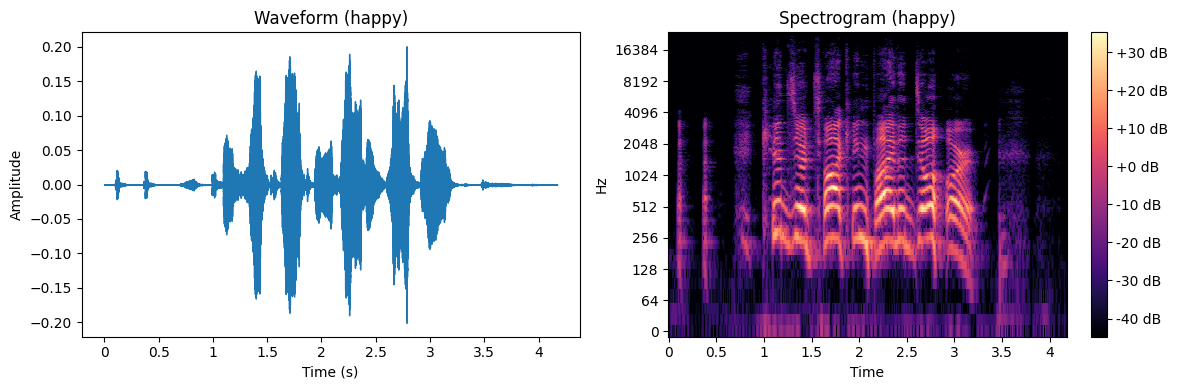

In [22]:
plt.figure(figsize=(12, 4))

# 1. Waveform
plt.subplot(1, 2, 1)
librosa.display.waveshow(signal, sr=sr)
plt.title("Waveform (happy)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# 2. Spectrogram
plt.subplot(1, 2, 2)
D = librosa.amplitude_to_db(abs(librosa.stft(signal)), ref=1.0)
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (happy)")

plt.tight_layout()
plt.show()

MFCC shape: (40, 392)


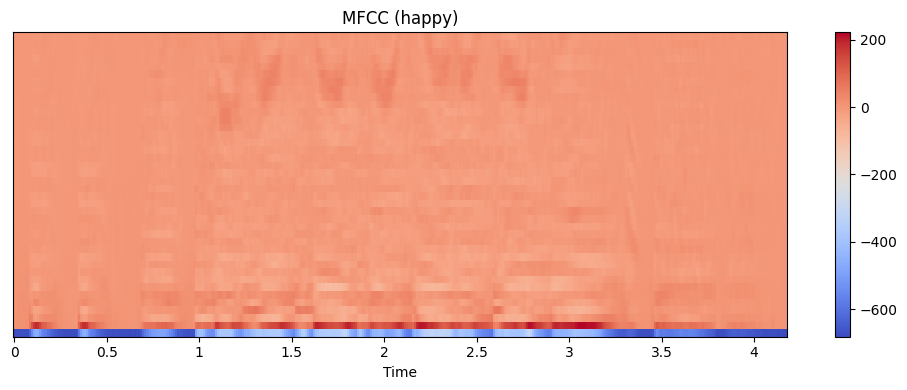

In [23]:
# Extract MFCC for the sample file
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
print("MFCC shape:", mfccs.shape)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, sr=sr, x_axis="time")
plt.colorbar()
plt.title("MFCC (happy)")
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

def extract_mfcc_mean(file_path, n_mfcc=40):
    signal, sr = librosa.load(file_path, sr=None)
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfccs.T, axis=0)  # average over time -> fixed-size vector

features = []
labels = []

for i, row in df.iterrows():
    try:
        mfcc_vector = extract_mfcc_mean(row["path"])
        features.append(mfcc_vector)
        labels.append(row["emotion"])
    except Exception as e:
        print("Error with file:", row["path"], e)

    if i % 200 == 0:
        print(f"Processed {i}/{len(df)} files...")

X = np.array(features)
y = np.array(labels)

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Processed 0/1440 files...
Processed 200/1440 files...
Processed 400/1440 files...
Processed 600/1440 files...
Processed 800/1440 files...
Processed 1000/1440 files...
Processed 1200/1440 files...
Processed 1400/1440 files...
Features shape: (1440, 40)
Labels shape: (1440,)


In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Encode emotion labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", list(le.classes_))

# 2. Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Train: (1152, 40)
Test: (288, 40)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    trained[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted"),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.438,0.432,0.438,0.427
SVM,0.594,0.631,0.594,0.575
Random Forest,0.649,0.653,0.649,0.637
MLP (Neural Network),0.733,0.732,0.733,0.730


<Figure size 800x700 with 0 Axes>

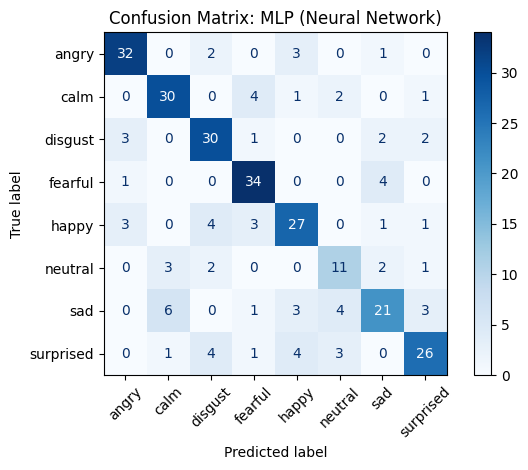

              precision    recall  f1-score   support

       angry       0.82      0.84      0.83        38
        calm       0.75      0.79      0.77        38
     disgust       0.71      0.79      0.75        38
     fearful       0.77      0.87      0.82        39
       happy       0.71      0.69      0.70        39
     neutral       0.55      0.58      0.56        19
         sad       0.68      0.55      0.61        38
   surprised       0.76      0.67      0.71        39

    accuracy                           0.73       288
   macro avg       0.72      0.72      0.72       288
weighted avg       0.73      0.73      0.73       288



In [27]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

best_model = trained["MLP (Neural Network)"]
y_pred = best_model.predict(X_test_scaled)

# 1. Confusion matrix
plt.figure(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap="Blues",
    xticks_rotation=45
)
plt.title("Confusion Matrix: MLP (Neural Network)")
plt.tight_layout()
plt.show()

# 2. Detailed report
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [28]:
import random

# Pick a few random test samples and compare prediction vs actual
sample_indices = random.sample(range(len(X_test)), 5)

for idx in sample_indices:
    true_label = le.classes_[y_test[idx]]
    pred_label = le.classes_[y_pred[idx]]
    match = "✅" if true_label == pred_label else "❌"
    print(f"{match} True: {true_label:10s} | Predicted: {pred_label}")

✅ True: surprised  | Predicted: surprised
✅ True: happy      | Predicted: happy
❌ True: surprised  | Predicted: disgust
✅ True: surprised  | Predicted: surprised
✅ True: fearful    | Predicted: fearful


## Conclusion

- **Best model:** MLP (Neural Network) achieved the best results, with 73.3% accuracy and a weighted F1-score of 0.730 on 8-way emotion classification, far above the 12.5% random-guess baseline.
- **Model comparison:** Logistic Regression (43.8%) struggled with this high-dimensional, non-linear problem. SVM (59.4%) and Random Forest (64.9%) performed progressively better, but the neural network captured the complex patterns in the MFCC features best.
- **Most confused emotions:** neutral and sad were the hardest to classify (recall 0.58 and 0.55), frequently confused with calm, since these emotions share similar low-energy vocal characteristics. Fearful and angry were the easiest to recognize (recall 0.87 and 0.84), as they have more distinct acoustic signatures.
- **Approach:** audio signals were converted into 40 MFCC coefficients, averaged over time into a fixed-size feature vector per sample, similar to how spectral features are extracted from time-series signals in other domains such as seismology.
- **Possible improvements:** using the full time-sequence of MFCCs with an LSTM or CNN instead of time-averaged features, data augmentation (pitch shifting, noise injection), and combining MFCCs with other features like chroma and spectral contrast.

# CodeAlpha Internship: Speech Emotion Recognition

**Objective:** Recognize human emotions (angry, calm, disgust, fearful, happy, neutral, sad, surprised) from speech audio, using MFCC feature extraction and comparing classical ML models with a neural network.

**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song), 1440 audio samples from 24 actors, 8 emotion classes.